## Tâches dans ce notebook:
  - Sélectionner trois couleurs distinctes.
  - Attribuer une couleur à chaque province de Madagascar, en veillant à utiliser uniquement les trois couleurs choisies.
  - S'assurer qu'aucune province voisine ne partage la même couleur.

## Provinces de Madagascar non colorées

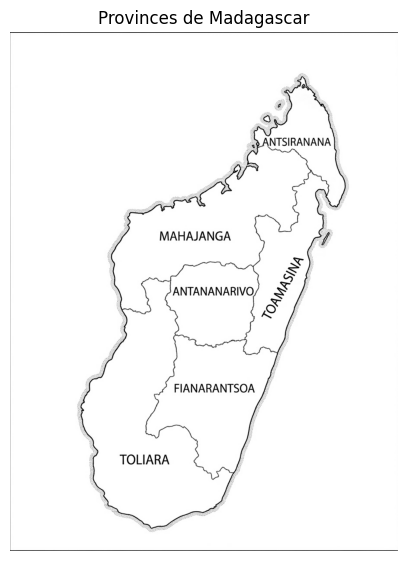

In [21]:
from PIL import Image
import matplotlib.pyplot as plt

img_pil = Image.open('provinces.png').convert('L')
plt.imshow(img_pil, cmap='gray')
plt.axis('off')
plt.title("Provinces de Madagascar")
plt.gcf().set_size_inches(5, 7)
plt.show()

## Liens entre provinces

In [22]:
# Madagascar's provinces and their neighboring links
MDG_PROVINCES = {
    "Antsiranana": ["Mahajanga", "Toamasina"],
    "Mahajanga": ["Antsiranana", "Toamasina", "Antananarivo", "Toliara"],
    "Toamasina": ["Antsiranana", "Mahajanga", "Antananarivo", "Fianarantsoa"],
    "Antananarivo": ["Mahajanga", "Toamasina", "Fianarantsoa", "Toliara"],
    "Fianarantsoa": ["Toamasina", "Antananarivo", "Toliara"],
    "Toliara": ["Mahajanga", "Antananarivo", "Fianarantsoa"]
}

COLORS = {
    "orange": (255, 179, 102),  # orange
    "bleue": (144, 202, 249),  # bleue
    "light green": (165, 214, 167),  # light green
}

## Recherche des bonnes couleurs pour la coloration

In [23]:
from itertools import product 

def valid_colors(colors, nbs):
    for pv, pc in colors.items():
        if any(colors[nb]==pc for nb in nbs[pv]):
            return False
    return True

def find_colors(base_colors, nbs):
    solutions = []
    for perm in product(base_colors.keys(),repeat=6):
        colors = {prv: cl for prv,cl in zip(nbs.keys(), perm)}
        if valid_colors(colors, nbs):
            solutions.append(colors)
        
    return solutions

In [24]:
SOLUTIONS = find_colors(COLORS, MDG_PROVINCES)
assert SOLUTIONS != [], "Did not find any solution"

print(f"Found {len(SOLUTIONS)} solutions !!")

Found 6 solutions !!


## Provinces de Madagascar colorées

In [25]:
import numpy as np
from skimage import measure
import matplotlib.pyplot as plt

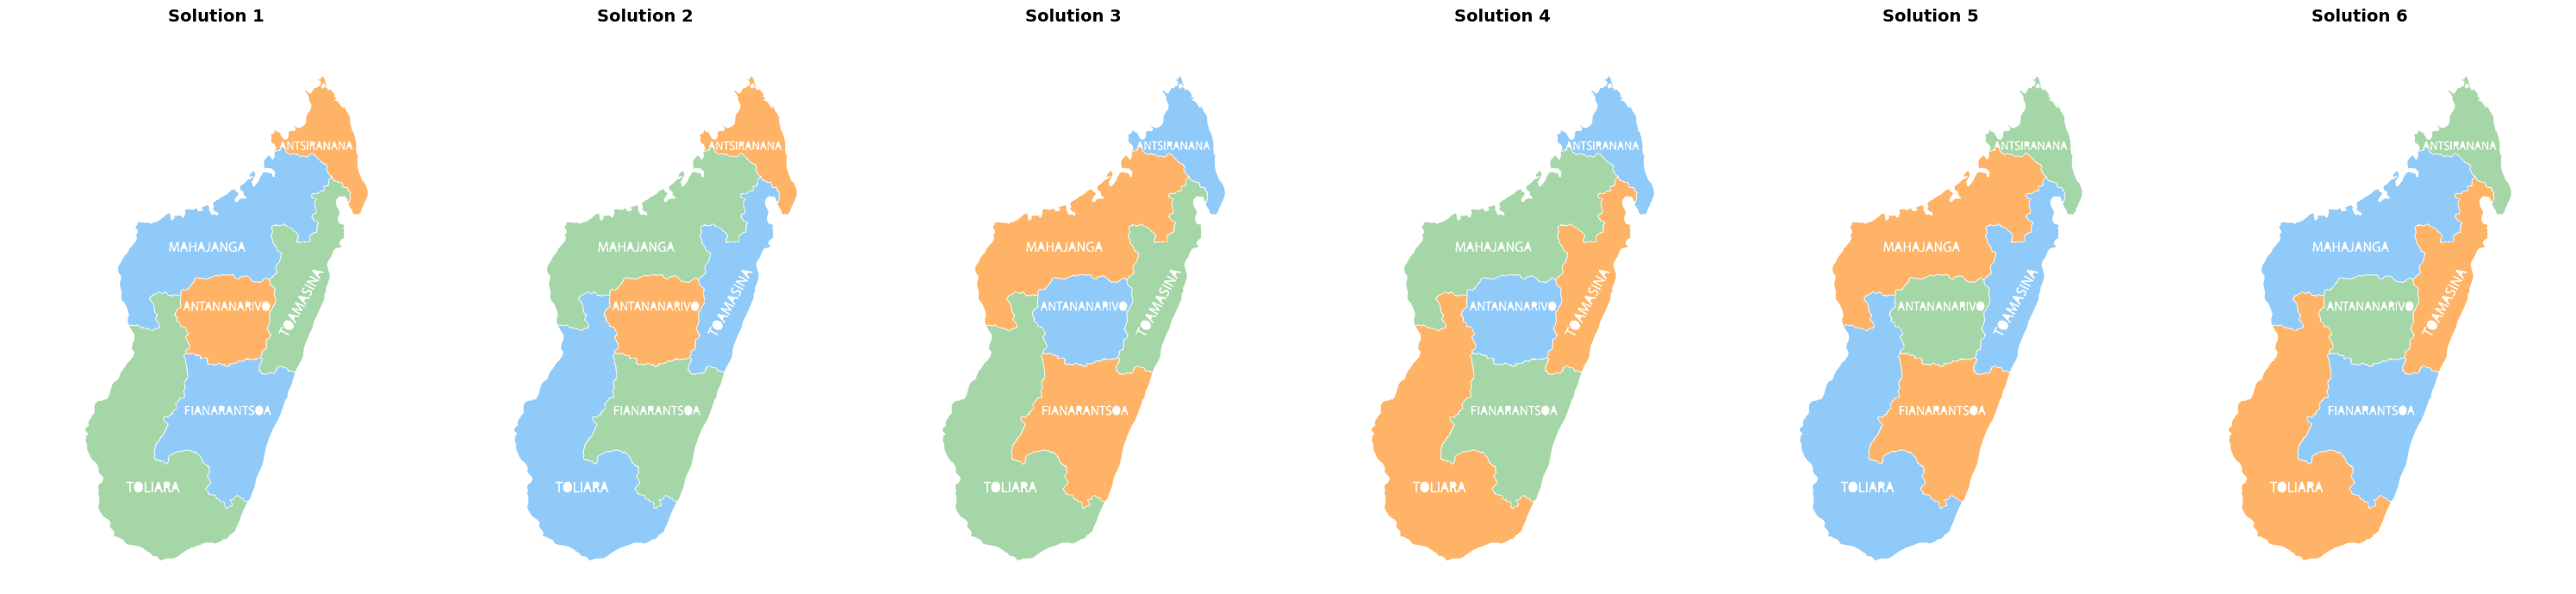

In [ ]:
show_order = ["Antsiranana", "Mahajanga", "Toamasina", "Antananarivo", "Toliara", "Fianarantsoa"]
num_solutions = len(SOLUTIONS)
fig, axes = plt.subplots(1, num_solutions, figsize=(5*num_solutions, 7))

MIN_AREA = 3000
MAX_AREA = 100000

if num_solutions == 1:
    axes = [axes]
    
for idx, (sol, ax) in enumerate(zip(SOLUTIONS, axes)):
    sol_colors = [COLORS[sol[prv]] for prv in show_order]
    
    # Conduct the same steps as plot_solution, but plotting on ax
    gray = np.array(img_pil)
    
    # Detect borders
    borders = (gray > 150).astype(np.uint8) * 255
    labeled = measure.label(borders, connectivity=1)
    
    # Detect region in the borders
    regions = measure.regionprops(labeled)
    
    # Remove noises
    provinces = [r for r in regions if MIN_AREA < r.area < MAX_AREA]
    
    # Colorize provinces
    output = np.ones((*gray.shape, 3), dtype=np.uint8) * 255
    for i, region in enumerate(provinces):
        output[labeled == region.label] = sol_colors[i % len(sol_colors)]
        
    # Plot the subplot (the current solution)
    ax.imshow(output)
    ax.axis('off')
    ax.set_title(f"Solution {idx+1}", fontsize=14, fontweight='bold')
    
plt.tight_layout()
plt.show()